#  Plant Disease Classifier
## Step 2: PyTorch Basics for Images

**What we did :**
- How images become tensors (numbers)
- What transforms are and why we need them
- How DataLoaders feed data in batches
- How we prepared the PlantVillage dataset for training


## Cell 1: Install & Import Libraries
 let's make sure all required libraries are available.

- `torch` → PyTorch core (tensors, models)
- `torchvision` → image datasets and transforms
- `sklearn` → for splitting data into train/val/test
- `matplotlib` → for visualizing images

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image

print(' All libraries imported successfully!')
print(f' PyTorch version: {torch.__version__}')
print(f' Using device: {"GPU " if torch.cuda.is_available() else "CPU (no GPU found)"}')

 All libraries imported successfully!
 PyTorch version: 2.5.1+cu121
 Using device: GPU 


---
## Cell 2: Understanding Images as Numbers

Neural networks **only understand numbers**. So every image must be converted to a **tensor**.

flower.jpg  →  Tensor shape: [3, 224, 224]
                               │    │    │
                           channels Height Width
                           (R, G, B)


Let's **see** this transformation with a real image from your dataset.

In [2]:
import os

DATA_DIR = "../data/PlantVillage"

classes  = os.listdir(DATA_DIR)
healthy  = [c for c in classes if 'healthy' in c.lower()]
diseased = [c for c in classes if 'healthy' not in c.lower()]

print(f" Total classes   : {len(classes)}")
print(f" Healthy folders  : {len(healthy)}")
print(f" Diseased folders : {len(diseased)}")

# Count total images
total = 0
for c in classes:
    imgs = os.listdir(f"{DATA_DIR}/{c}")
    total += len(imgs)
    
print(f" Total images    : {total}")

 Total classes   : 15
 Healthy folders  : 3
 Diseased folders : 12
 Total images    : 20639


---
##  Cell 3: Look at a Real Image

Let's open one image and see what it looks like **before** and **after** converting to a tensor.

 Class  : Pepper__bell___Bacterial_spot
 File   : 0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG
 Size   : (256, 256)  (width x height)
 Mode   : RGB (RGB = 3 channels)


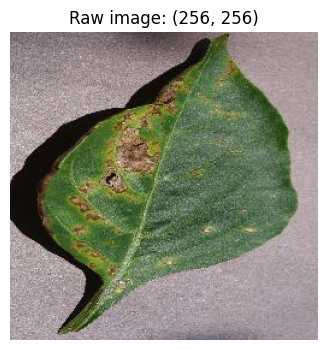

In [3]:
# Pick the first image from the first class folder
first_class  = classes[0]
class_folder = os.path.join(DATA_DIR, first_class)
first_image  = os.listdir(class_folder)[0]
image_path   = os.path.join(class_folder, first_image)

# Open the image with PIL (Python Imaging Library)
img = Image.open(image_path)

print(f" Class  : {first_class}")
print(f" File   : {first_image}")
print(f" Size   : {img.size}  (width x height)")
print(f" Mode   : {img.mode} (RGB = 3 channels)")

# Show the image
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Raw image: {img.size}")
plt.axis('off')
plt.show()

In [4]:
# Now convert this image to a TENSOR manually
to_tensor = transforms.ToTensor()
img_tensor = to_tensor(img)

print(" After converting to tensor:")
print(f"   Shape  : {img_tensor.shape}")
print(f"            └─ [channels=3, height={img_tensor.shape[1]}, width={img_tensor.shape[2]}]")
print(f"   Min value : {img_tensor.min():.3f}")
print(f"   Max value : {img_tensor.max():.3f}")
print(f"   Dtype     : {img_tensor.dtype}")

#  LEARNING CHECKPOINT
# Notice pixel values are between 0.0 and 1.0 (not 0-255)
# ToTensor() automatically divides by 255!

 After converting to tensor:
   Shape  : torch.Size([3, 256, 256])
            └─ [channels=3, height=256, width=256]
   Min value : 0.000
   Max value : 1.000
   Dtype     : torch.float32


---
## Cell 4: Understanding Transforms

**Transforms** are a pipeline of operations applied to every image.

Different transforms are used for **training** vs **validation**:

| Transform | Training | Validation | Purpose |
|-----------|----------|------------|---------|
| Resize(224,224) | Y | Y | MobileNetV3 requires this input size |
| RandomHorizontalFlip | Y | N | Data augmentation — improves model robustness |
| RandomRotation | Y | N | Data augmentation only |
| ToTensor | Y | Y | Required for all inputs |
| Normalize | Y | Y | Standardizes pixel values |

In [5]:
# Define the transforms we'll use

# --- TRAINING transforms (with augmentation) ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # Resize to 224x224 (required by MobileNetV3)
    transforms.RandomHorizontalFlip(),   # Randomly flip left-right (50% chance)
    transforms.RandomRotation(15),       # Rotate randomly up to 15 degrees
    transforms.ToTensor(),               # Convert PIL image → tensor (values 0-1)
    transforms.Normalize(                # Normalize using ImageNet mean & std
        mean=[0.485, 0.456, 0.406],      # These are the STANDARD values used for
        std =[0.229, 0.224, 0.225]       # ALL pretrained ImageNet models
    )
])

# --- VALIDATION/TEST transforms (no augmentation) ---
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print(" Transforms defined!")
print("\n Training pipeline:")
for i, t in enumerate(train_transforms.transforms):
    print(f"   Step {i+1}: {t}")

 Transforms defined!

 Training pipeline:
   Step 1: Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
   Step 2: RandomHorizontalFlip(p=0.5)
   Step 3: RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
   Step 4: ToTensor()
   Step 5: Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


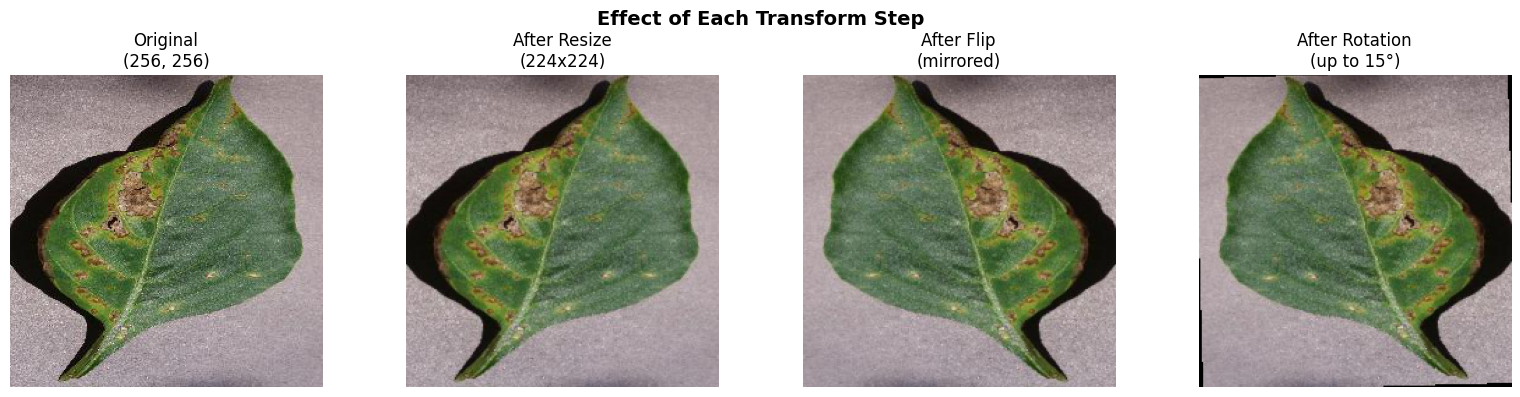

 Each training epoch, images get randomly flipped/rotated — this helps the model generalize!


In [6]:
# VISUALIZE: See the effect of transforms on the same image

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Effect of Each Transform Step', fontsize=14, fontweight='bold')

# Original image
axes[0].imshow(img)
axes[0].set_title(f'Original\n{img.size}')
axes[0].axis('off')

# After resize
resized = transforms.Resize((224, 224))(img)
axes[1].imshow(resized)
axes[1].set_title('After Resize\n(224x224)')
axes[1].axis('off')

# After random flip
flipped = transforms.RandomHorizontalFlip(p=1.0)(resized)  # p=1.0 forces flip
axes[2].imshow(flipped)
axes[2].set_title('After Flip\n(mirrored)')
axes[2].axis('off')

# After rotation
rotated = transforms.RandomRotation(15)(flipped)
axes[3].imshow(rotated)
axes[3].set_title('After Rotation\n(up to 15°)')
axes[3].axis('off')

plt.tight_layout()
plt.show()
print(" Each training epoch, images get randomly flipped/rotated — this helps the model generalize!")

---
## 🏷 Cell 5: Binary Label Mapping

PlantVillage has **38 classes** (different plant diseases). But we only want **2 labels**:
- `0` = Healthy  
- `1` = Diseased

We just check: does the folder name contain the word **'healthy'**?

In [7]:
# Load dataset with ImageFolder (automatically uses folder names as labels)
raw_dataset = datasets.ImageFolder(root=DATA_DIR)

print(f" Original classes ({len(raw_dataset.classes)} total):")
for i, c in enumerate(raw_dataset.classes):
    binary = 0 if 'healthy' in c.lower() else 1
    label  = ' Healthy (0)' if binary == 0 else ' Diseased (1)'
    print(f"   {i:2d}. {c:<45} → {label}")

 Original classes (15 total):
    0. Pepper__bell___Bacterial_spot                 →  Diseased (1)
    1. Pepper__bell___healthy                        →  Healthy (0)
    2. Potato___Early_blight                         →  Diseased (1)
    3. Potato___Late_blight                          →  Diseased (1)
    4. Potato___healthy                              →  Healthy (0)
    5. Tomato_Bacterial_spot                         →  Diseased (1)
    6. Tomato_Early_blight                           →  Diseased (1)
    7. Tomato_Late_blight                            →  Diseased (1)
    8. Tomato_Leaf_Mold                              →  Diseased (1)
    9. Tomato_Septoria_leaf_spot                     →  Diseased (1)
   10. Tomato_Spider_mites_Two_spotted_spider_mite   →  Diseased (1)
   11. Tomato__Target_Spot                           →  Diseased (1)
   12. Tomato__Tomato_YellowLeaf__Curl_Virus         →  Diseased (1)
   13. Tomato__Tomato_mosaic_virus                   →  Diseased (1)
   14.

In [8]:
# Define our binary conversion function
def get_binary_label(original_label, class_names):
    """
    Converts a 38-class label into binary:
      0 = Healthy
      1 = Diseased
    """
    class_name = class_names[original_label]
    return 0 if 'healthy' in class_name.lower() else 1


# Quick test
sample_labels = [0, 1, 5, 12, 14]
print(" Testing binary label conversion:")
for lbl in sample_labels:
    binary = get_binary_label(lbl, raw_dataset.classes)
    print(f"   Class {lbl:2d}: '{raw_dataset.classes[lbl]}' → {binary} ({'Healthy' if binary==0 else 'Diseased'})")

 Testing binary label conversion:
   Class  0: 'Pepper__bell___Bacterial_spot' → 1 (Diseased)
   Class  1: 'Pepper__bell___healthy' → 0 (Healthy)
   Class  5: 'Tomato_Bacterial_spot' → 1 (Diseased)
   Class 12: 'Tomato__Tomato_YellowLeaf__Curl_Virus' → 1 (Diseased)
   Class 14: 'Tomato_healthy' → 0 (Healthy)


---
##  Cell 6: Custom Dataset Class

In PyTorch, a **Dataset** is a class with 3 methods:
- `__init__` → set up the dataset
- `__len__` → how many items total?
- `__getitem__` → get item at index `i`

We wrap PyTorch's `ImageFolder` to return **binary labels** instead of 38-class labels.

In [9]:
class PlantDiseaseDataset(torch.utils.data.Dataset):
    """
    Custom Dataset that wraps ImageFolder.
    Returns binary labels: 0=Healthy, 1=Diseased
    """
    def __init__(self, subset, class_names):
        self.subset      = subset        # The underlying data (images)
        self.class_names = class_names   # Original 38 class names

    def __len__(self):
        # PyTorch calls this to know how many images we have
        return len(self.subset)

    def __getitem__(self, idx):
        # Get one image and its ORIGINAL label (0-37)
        image, original_label = self.subset[idx]

        # Convert to BINARY label (0 or 1)
        binary_label = get_binary_label(original_label, self.class_names)

        return image, binary_label


print(" PlantDiseaseDataset class defined!")
print("\n Key concept:")
print("   __len__      → tells PyTorch total number of images")
print("   __getitem__  → called millions of times during training")
print("                  returns ONE image + its binary label")

 PlantDiseaseDataset class defined!

 Key concept:
   __len__      → tells PyTorch total number of images
   __getitem__  → called millions of times during training
                  returns ONE image + its binary label


---
##  Cell 7: Train / Validation / Test Split

We split our data into 3 sets:

```
All Images (100%)
│
├── Train (70%)    → Model LEARNS from this
├── Validation (15%) → Check performance DURING training
└── Test (15%)     → Final evaluation AFTER training
```

 **Important:** Test set is **never** seen during training. It's our honest final score.

In [10]:
# Load dataset twice — once for train transforms, once for val transforms
train_folder = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_folder   = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)
class_names  = train_folder.classes

# All indices and their labels (for stratified split)
all_indices = list(range(len(train_folder)))
all_labels  = train_folder.targets  # Original 0-37 labels

# SPLIT 1: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    all_indices,
    test_size   = 0.30,
    stratify    = all_labels,    # Ensures each class is equally represented in splits
    random_state= 42             # For reproducibility (same split every time)
)

# SPLIT 2: 50% of temp → val, 50% → test  (i.e., 15% + 15%)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size   = 0.50,
    stratify    = temp_labels,
    random_state= 42
)

print(f" Dataset split:")
print(f"   Total   : {len(all_indices):,} images")
print(f"   Train   : {len(train_idx):,} images  ({len(train_idx)/len(all_indices)*100:.0f}%)")
print(f"   Val     : {len(val_idx):,} images  ({len(val_idx)/len(all_indices)*100:.0f}%)")
print(f"   Test    : {len(test_idx):,} images  ({len(test_idx)/len(all_indices)*100:.0f}%)")

 Dataset split:
   Total   : 20,638 images
   Train   : 14,446 images  (70%)
   Val     : 3,096 images  (15%)
   Test    : 3,096 images  (15%)


---
##  Cell 8: DataLoaders - Batching the Data

A **DataLoader** wraps a Dataset and:
- Splits it into **batches** (e.g., 32 images at a time)
- **Shuffles** training data each epoch
- Loads images in **parallel** (faster training)

```
DataLoader (batch_size=32)
│
├── Batch 1: images[32, 3, 224, 224], labels[32]
├── Batch 2: images[32, 3, 224, 224], labels[32]
└── ...continues until all images are used (= 1 epoch)
```

In [11]:
BATCH_SIZE = 32

# Create Dataset objects
train_dataset = PlantDiseaseDataset(Subset(train_folder, train_idx), class_names)
val_dataset   = PlantDiseaseDataset(Subset(val_folder,   val_idx),   class_names)
test_dataset  = PlantDiseaseDataset(Subset(val_folder,   test_idx),  class_names)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,     # ← Shuffle training data every epoch
    num_workers= 0         # Workers for parallel loading (0 = main thread)
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False     # ← Never shuffle val/test
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False
)

print(f" DataLoaders created!")
print(f"\n Batches per epoch:")
print(f"   Train : {len(train_loader):,} batches  (each = {BATCH_SIZE} images)")
print(f"   Val   : {len(val_loader):,} batches")
print(f"   Test  : {len(test_loader):,} batches")

 DataLoaders created!

 Batches per epoch:
   Train : 452 batches  (each = 32 images)
   Val   : 97 batches
   Test  : 97 batches


---
##  Cell 9: Verify Everything Works

Let's grab **one batch** and inspect it - this confirms our whole pipeline works.

In [12]:
# Grab one batch from train_loader
images, labels = next(iter(train_loader))

print(" Inspecting one batch:")
print(f"   images.shape : {images.shape}")
print(f"                  └─ [batch=32, channels=3, height=224, width=224]")
print(f"   labels.shape : {labels.shape}")
print(f"   Label values : {labels.unique()}  ← Should be only 0 and 1")
print(f"   Healthy in batch  : {(labels==0).sum().item()} images")
print(f"   Diseased in batch : {(labels==1).sum().item()} images")
print(f"\n   Pixel value range: [{images.min():.3f}, {images.max():.3f}]  ← After normalization")

 Inspecting one batch:
   images.shape : torch.Size([32, 3, 224, 224])
                  └─ [batch=32, channels=3, height=224, width=224]
   labels.shape : torch.Size([32])
   Label values : tensor([0, 1])  ← Should be only 0 and 1
   Healthy in batch  : 6 images
   Diseased in batch : 26 images

   Pixel value range: [-2.118, 2.605]  ← After normalization


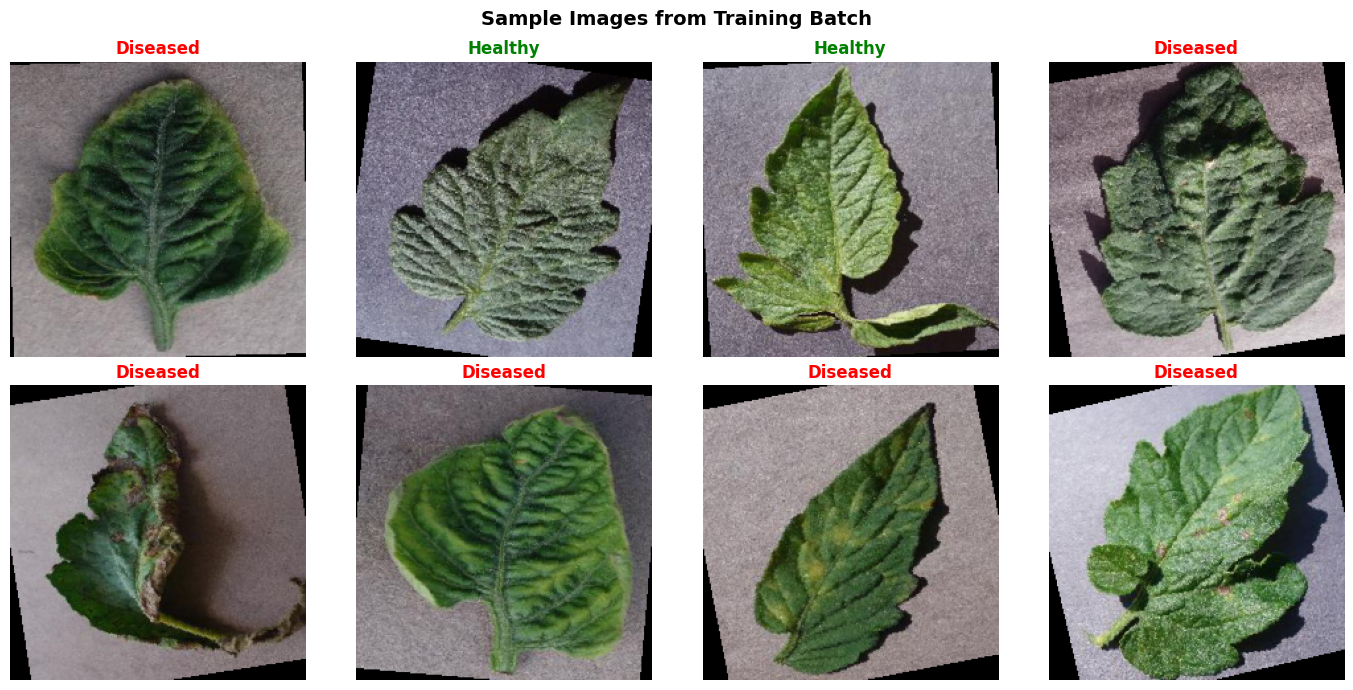

In [13]:
# VISUALIZE: Show 8 images from the batch with their labels

# Helper: undo normalization for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Images from Training Batch', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img_display = denormalize(images[i]).permute(1, 2, 0).numpy()
    label       = labels[i].item()
    color       = 'green' if label == 0 else 'red'
    title       = 'Healthy' if label == 0 else 'Diseased'  # ← no emojis
    
    ax.imshow(img_display)
    ax.set_title(title, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
##  Cell 10: Save Everything for Next Steps

We'll save our key variables so we can import them in future notebooks.

In [14]:
# Create src folder if it doesn't exist
os.makedirs('src', exist_ok=True)

# Save dataset.py for use in later notebooks
dataset_code = '''
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_binary_label(original_label, class_names):
    return 0 if "healthy" in class_names[original_label].lower() else 1

class PlantDiseaseDataset(torch.utils.data.Dataset):
    def __init__(self, subset, class_names):
        self.subset = subset
        self.class_names = class_names
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        image, original_label = self.subset[idx]
        return image, get_binary_label(original_label, self.class_names)

def get_dataloaders(data_dir="./data/PlantVillage", batch_size=32):
    train_folder = datasets.ImageFolder(root=data_dir, transform=train_transforms)
    val_folder   = datasets.ImageFolder(root=data_dir, transform=val_transforms)
    class_names  = train_folder.classes
    all_indices  = list(range(len(train_folder)))
    all_labels   = train_folder.targets
    train_idx, temp_idx = train_test_split(all_indices, test_size=0.30, stratify=all_labels, random_state=42)
    temp_labels  = [all_labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=temp_labels, random_state=42)
    train_ds = PlantDiseaseDataset(Subset(train_folder, train_idx), class_names)
    val_ds   = PlantDiseaseDataset(Subset(val_folder,   val_idx),   class_names)
    test_ds  = PlantDiseaseDataset(Subset(val_folder,   test_idx),  class_names)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
    return train_loader, val_loader, test_loader, class_names
'''

with open('src/dataset.py', 'w') as f:
    f.write(dataset_code)

print(" src/dataset.py saved!")
print("\n Step 2 Complete! Here's what you learned:")
print("   1. Images are tensors of shape [3, 224, 224]")
print("   2. Transforms resize, augment and normalize images")
print("   3. Custom Dataset class returns (image, binary_label) pairs")
print("   4. DataLoaders batch and shuffle data for training")
print("   5. We split data 70/15/15 for train/val/test")
print("\n  Next: Step 3 — Transfer Learning & MobileNetV3")

 src/dataset.py saved!

 Step 2 Complete! Here's what you learned:
   1. Images are tensors of shape [3, 224, 224]
   2. Transforms resize, augment and normalize images
   3. Custom Dataset class returns (image, binary_label) pairs
   4. DataLoaders batch and shuffle data for training
   5. We split data 70/15/15 for train/val/test

  Next: Step 3 — Transfer Learning & MobileNetV3


---
##  Step 2 Summary - What You Learned

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Tensor** | Multi-dimensional array of numbers | Neural networks only understand numbers |
| **Transforms** | Pipeline of image operations | Resize, normalize, augment images |
| **Augmentation** | Random flips/rotations during training | Makes model more robust |
| **Normalization** | Scale pixels to standard range | Required for pretrained models |
| **Dataset class** | Python class with `__len__` and `__getitem__` | PyTorch's interface for loading data |
| **DataLoader** | Batches + shuffles a Dataset | Efficiently feeds data during training |
| **Train/Val/Test split** | 70/15/15 division | Prevents overfitting, honest evaluation |

---


